In [1]:
import pandas as pd

In [2]:
data1=pd.read_csv("job_descriptions.csv")
data2=pd.read_csv("resumes.csv")

In [3]:
job_descriptions=pd.DataFrame(data1)
resumes=pd.DataFrame(data2)

In [4]:
job_descriptions

,role,category,required_skills,preferred_skills,experience_required,education_required,job_description
0,Data Scientist,Data Science,"Python, Machine Learning, scikit-learn, SQL, S...","Deep Learning, TensorFlow, NLP, Tableau, Featu...",1–3 years,"B.Tech/M.Tech in CSE, Statistics, or related f...",We are looking for a Data Scientist to join ou...
1,Full Stack Web Developer,Web Development,"JavaScript, React, Node.js, MongoDB, REST API,...","TypeScript, Docker, AWS, Next.js, GraphQL",1–2 years,B.Tech/BCA/MCA in CSE or IT,We are hiring a Full Stack Developer to build ...
2,DevOps Engineer,DevOps,"Docker, Kubernetes, CI/CD, Linux, AWS, Git, Sh...","Terraform, Ansible, Prometheus, Grafana, Jenkins",2–4 years,B.Tech in CSE/IT or equivalent,We are seeking a DevOps Engineer to manage inf...
3,Android Developer,Android Development,"Kotlin, Android SDK, REST API, Firebase, MVVM,...","Jetpack Compose, Coroutines, Hilt, Room Databa...",1–3 years,B.Tech/BCA/MCA in CSE or IT,We are looking for an Android Developer to des...
4,Data Engineer,Data Engineering,"Python, SQL, Apache Spark, ETL Pipelines, Data...","Kafka, Airflow, Snowflake, dbt, BigQuery, Docker",2–4 years,B.Tech/M.Tech in CSE or Data Science,We are hiring a Data Engineer to build and mai...
5,HR Executive,HR,"Recruitment, Onboarding, HRMS, Employee Relati...","Payroll, Performance Management, Talent Acquis...",1–3 years,MBA HR / BBA HR or equivalent,We are looking for an HR Executive to manage e...


In [5]:
resumes[resumes["certifications"].isnull()==False]

,candidate_name,category,fit_level,experience_years,education,skills,certifications,resume_text
2,Hemangini Lalla,Data Science,high,4,M.Sc Data Science,"Deep Learning, Statistics, NumPy, Feature Engi...","IBM Data Science Professional, TensorFlow Deve...",Name: Hemangini Lalla\nEmail: sharafjeet@examp...
6,Imaran Dua,Data Science,medium,3,B.Sc Mathematics,"Machine Learning, OpenCV, NLP, NLTK, XGBoost, ...","IBM Data Science Professional, AWS ML Specialty",Name: Imaran Dua\nEmail: pahalbhatt@example.co...
7,Chaaya Saran,Data Science,medium,1,B.Sc Mathematics,"Python, LightGBM, XGBoost, Pandas, Machine Lea...",IBM Data Science Professional,Name: Chaaya Saran\nEmail: sudikshaaggarwal@ex...
9,Kabir Soman,Data Science,medium,1,B.Sc Statistics,"XGBoost, Python, Machine Learning, NLTK, Panda...",Coursera ML Specialization,Name: Kabir Soman\nEmail: alkawable@example.ne...
10,Umang Bhatt,Data Science,medium,1,B.Tech CSE,"LightGBM, OpenCV, XGBoost, R, Seaborn, Machine...","Google Data Analytics Certificate, IBM Data Sc...",Name: Umang Bhatt\nEmail: ansh98@example.org |...
11,Arya Sunder,Data Science,medium,1,B.Sc Mathematics,"Keras, Seaborn, Pandas, NumPy, Statistics, Ten...","IBM Data Science Professional, AWS ML Specialty",Name: Arya Sunder\nEmail: kevinsolanki@example...
12,Darsh Rau,Data Science,medium,3,B.Tech CSE,"Matplotlib, Jupyter Notebook, spaCy, Tableau, ...",AWS ML Specialty,Name: Darsh Rau\nEmail: ikbal33@example.org | ...
21,Nicholas Goel,Web Development,high,2,BCA,"Git, Bootstrap, AWS, Tailwind CSS, Redis, Next...",Google UX Design Certificate,Name: Nicholas Goel\nEmail: lbakshi@example.ne...
22,Inaya Mody,Web Development,high,2,Diploma in Web Development,"MySQL, REST API, Next.js, Bootstrap, Tailwind ...",Google UX Design Certificate,Name: Inaya Mody\nEmail: udantbajwa@example.ne...
23,Jack Lal,Web Development,high,5,B.Tech CSE,"Vue.js, TypeScript, Django, Flask, Tailwind CS...","freeCodeCamp Full Stack, AWS Developer Associate",Name: Jack Lal\nEmail: alkabarad@example.org |...


## ML Matching Engine — TF-IDF + Cosine Similarity

This section scores every resume against its matching job description and produces a ranked candidate list per role. (NLP entity extraction with spaCy and the LangChain/CrewAI multi-agent scoring layer will be added later — this notebook covers only the core ML matching pipeline for now.)

### Step 1: Imports

In [6]:
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

### Step 2: Clean the text

Strip emails, phone numbers, and punctuation out of the resume/job text so the vectorizer only sees meaningful words (skills, tools, experience terms) instead of noise.

In [7]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r'\S+@\S+', ' ', text)                 # remove emails
    text = re.sub(r'\+?\d[\d\-\s]{7,}\d', ' ', text)      # remove phone numbers
    text = re.sub(r'[^a-z\s]', ' ', text)                 # keep letters only
    text = re.sub(r'\s+', ' ', text).strip()
    return text

resumes['clean_text'] = resumes['resume_text'].apply(clean_text)

# job text = description + required skills + preferred skills (skills matter most, so this keeps them in the corpus)
job_descriptions['clean_text'] = (
    job_descriptions['job_description'].fillna('') + ' ' +
    job_descriptions['required_skills'].fillna('') + ' ' +
    job_descriptions['preferred_skills'].fillna('')
).apply(clean_text)

resumes[['candidate_name', 'clean_text']].head(3)

,candidate_name,clean_text
0,Aryan Maharaj,name aryan maharaj email phone location gurugr...
1,Rushil Saini,name rushil saini email phone location bengalu...
2,Hemangini Lalla,name hemangini lalla email phone location pune...


### Step 3: Ranking function

For a given job, take only the resumes from the same `category`, fit a TF-IDF vectorizer on (job text + those resumes), and compute cosine similarity between the job vector and every resume vector. Higher score = closer textual match to the job description.

In [8]:
def rank_candidates_for_job(job_row, resumes_df):
    candidates = resumes_df[resumes_df['category'] == job_row['category']].copy()
    if candidates.empty:
        return candidates

    corpus = [job_row['clean_text']] + candidates['clean_text'].tolist()
    vectorizer = TfidfVectorizer(stop_words='english')
    tfidf_matrix = vectorizer.fit_transform(corpus)

    job_vector = tfidf_matrix[0:1]
    resume_vectors = tfidf_matrix[1:]

    scores = cosine_similarity(job_vector, resume_vectors).flatten()
    candidates['match_score'] = scores
    candidates['match_percent'] = (scores * 100).round(2)
    candidates['job_role'] = job_row['role']

    return candidates.sort_values('match_score', ascending=False).reset_index(drop=True)

### Step 4: Rank candidates for every job role

In [9]:
all_rankings = []
for _, job_row in job_descriptions.iterrows():
    ranked = rank_candidates_for_job(job_row, resumes)
    all_rankings.append(ranked)

all_rankings_df = pd.concat(all_rankings, ignore_index=True)
all_rankings_df['rank'] = (
    all_rankings_df.groupby('job_role')['match_score']
    .rank(ascending=False, method='first')
    .astype(int)
)

all_rankings_df.shape

(120, 13)

### Step 5: Top 5 candidates per job

In [10]:
for role in job_descriptions['role']:
    print(f"\n=== Top 5 candidates: {role} ===")
    top5 = (
        all_rankings_df[all_rankings_df['job_role'] == role]
        .sort_values('rank')
        .head(5)[['rank', 'candidate_name', 'experience_years', 'fit_level', 'match_percent']]
    )
    print(top5.to_string(index=False))


=== Top 5 candidates: Data Scientist ===
 rank  candidate_name  experience_years fit_level  match_percent
    1 Hemangini Lalla                 4      high          26.78
    2   Aryan Maharaj                 2      high          26.70
    3    Rushil Saini                 5      high          25.11
    4   Neel Zacharia                 3    medium          24.37
    5 Viraj Chaudhuri                 2      high          21.80

=== Top 5 candidates: Full Stack Web Developer ===
 rank      candidate_name  experience_years fit_level  match_percent
    1            Jack Lal                 5      high          29.72
    2   Osha Ramachandran                 2    medium          29.23
    3          Inaya Mody                 2      high          27.69
    4 Vedika Balakrishnan                 1    medium          26.94
    5          Kala Divan                 3      high          25.56

=== Top 5 candidates: DevOps Engineer ===
 rank candidate_name  experience_years fit_level  match_per

### Step 6: Sanity check against the labeled `fit_level`

The dataset already has a ground-truth `fit_level` (high/medium/low) per resume. If the TF-IDF matching logic is doing something sensible, average match scores should increase from low → medium → high. This is a quick, free evaluation metric for the report.

In [11]:
fit_summary = (
    all_rankings_df.groupby('fit_level')['match_score']
    .agg(['mean', 'median', 'count'])
    .reindex(['high', 'medium', 'low'])
)
fit_summary

,mean,median,count
fit_level,,,
high,0.308263,0.297584,30
medium,0.269482,0.259851,48
low,0.171851,0.162836,42


/tmp/ipykernel_621/1104979198.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=order)


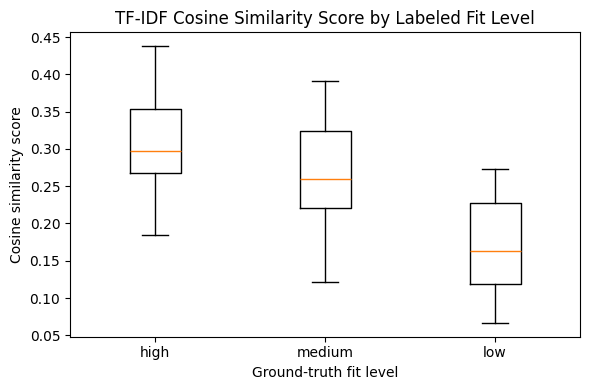

In [12]:
order = ['high', 'medium', 'low']
data_to_plot = [all_rankings_df[all_rankings_df['fit_level'] == lvl]['match_score'] for lvl in order]

plt.figure(figsize=(6, 4))
plt.boxplot(data_to_plot, labels=order)
plt.title('TF-IDF Cosine Similarity Score by Labeled Fit Level')
plt.ylabel('Cosine similarity score')
plt.xlabel('Ground-truth fit level')
plt.tight_layout()
plt.show()

### Step 7: Save ranked results

This is the output the NLP entity-extraction and LangChain/CrewAI agent layers will build on top of later — each resume already has a `match_score` / `match_percent` / `rank` against its matching job.

In [13]:
all_rankings_df.to_csv('ranked_candidates.csv', index=False)
all_rankings_df.sort_values(['job_role', 'rank']).head(10)

,candidate_name,category,fit_level,experience_years,education,skills,certifications,resume_text,clean_text,match_score,match_percent,job_role,rank
60,Watika Mangat,Android Development,high,2,B.Sc IT,"Android SDK, MVVM, Material Design, Coroutines...",Meta Android Developer Certificate,Name: Watika Mangat\nEmail: indirakanda@exampl...,name watika mangat email phone location hydera...,0.369188,36.92,Android Developer,1
61,Kalpit Zachariah,Android Development,medium,2,B.Sc IT,"Kotlin, Room Database, Git, Hilt, Coroutines, ...",Udacity Android Nanodegree,Name: Kalpit Zachariah\nEmail: owen10@example....,name kalpit zachariah email phone location noi...,0.362962,36.30,Android Developer,2
62,Kamala Kalla,Android Development,medium,2,BCA,"XML, Push Notifications, MVVM, Android SDK, RE...",NaN,Name: Kamala Kalla\nEmail: psaxena@example.com...,name kamala kalla email phone location chennai...,0.357139,35.71,Android Developer,3
63,Vivaan Sinha,Android Development,high,4,B.Sc IT,"MVVM, REST API, SQLite, LiveData, Google Maps ...","Google Associate Android Developer, Udacity An...",Name: Vivaan Sinha\nEmail: narangtimothy@examp...,name vivaan sinha email phone location mumbai ...,0.354316,35.43,Android Developer,4
64,Faqid Dhaliwal,Android Development,high,2,B.Tech IT,"Jetpack Compose, MVVM, Retrofit, Firebase, Liv...",NaN,Name: Faqid Dhaliwal\nEmail: mekhalapau@exampl...,name faqid dhaliwal email phone location mumba...,0.338353,33.84,Android Developer,5
65,Devansh Soni,Android Development,medium,1,B.Tech CSE,"Unit Testing, Push Notifications, Java, Jetpac...","Meta Android Developer Certificate, Google Ass...",Name: Devansh Soni\nEmail: gpathak@example.net...,name devansh soni email phone location chennai...,0.330436,33.04,Android Developer,6
66,Jason Roy,Android Development,medium,3,B.Tech CSE,"Navigation Component, Material Design, ViewMod...","Udacity Android Nanodegree, Google Associate A...",Name: Jason Roy\nEmail: pallavi04@example.net ...,name jason roy email phone location hyderabad ...,0.327484,32.75,Android Developer,7
67,Dhriti Sane,Android Development,medium,1,BCA,"Material Design, ViewModel, Kotlin, Coroutines...","Udacity Android Nanodegree, Google Associate A...",Name: Dhriti Sane\nEmail: aadhya52@example.net...,name dhriti sane email phone location chennai ...,0.322319,32.23,Android Developer,8
68,Chaitaly Setty,Android Development,medium,1,B.Tech CSE,"Git, Jetpack Compose, Material Design, LiveDat...","Udacity Android Nanodegree, Meta Android Devel...",Name: Chaitaly Setty\nEmail: ychaudhary@exampl...,name chaitaly setty email phone location pune ...,0.309591,30.96,Android Developer,9
69,Wahab Yogi,Android Development,high,5,MCA,"ViewModel, Room Database, Material Design, MVV...",Udacity Android Nanodegree,Name: Wahab Yogi\nEmail: lipikasetty@example.c...,name wahab yogi email phone location mumbai ed...,0.294931,29.49,Android Developer,10


## NLP Entity Extraction Layer (spaCy)

`resume_text` is one unstructured blob per candidate, but it turns out to follow a consistent template (`Name / Email / Phone / Location`, then `EDUCATION`, `SKILLS`, `EXPERIENCE`, `PROJECTS`, `CERTIFICATIONS`, `LANGUAGES` sections). That means we can get high-precision fields with regex/section-parsing for the templated parts, and use spaCy specifically where it adds real value: matching skills mentioned anywhere in the free text (not just the SKILLS line — e.g. a tool mentioned only in a project description), and named-entity recognition for company names.

Output of this section: `enriched_candidates.csv`, which the CrewAI agent layer will consume later.

### Setup

Try to load spaCy's full pretrained pipeline (`en_core_web_sm`) for statistical NER. If it isn't available (e.g. no internet access to download it), fall back to a blank English pipeline — rule-based extraction (regex + PhraseMatcher) still works fully either way; only the optional NER-based company-name step is affected.

In [14]:
import re
import spacy
from spacy.matcher import PhraseMatcher

try:
    nlp = spacy.load('en_core_web_sm')
    HAS_FULL_MODEL = True
    print('Loaded en_core_web_sm (full statistical NER available)')
except OSError:
    nlp = spacy.blank('en')
    HAS_FULL_MODEL = False
    print('en_core_web_sm not installed (run: python -m spacy download en_core_web_sm) — '
          'falling back to a blank pipeline. Regex + PhraseMatcher extraction below is unaffected; '
          'only the optional company-name NER step will be skipped.')

en_core_web_sm not installed (run: python -m spacy download en_core_web_sm) — falling back to a blank pipeline. Regex + PhraseMatcher extraction below is unaffected; only the optional company-name NER step will be skipped.


### Step 1: Contact fields via regex

Email is the one field the rejection-email feature absolutely depends on, so it gets extracted first and checked for completeness.

In [15]:
def extract_field(pattern, text):
    if pd.isna(text):
        return None
    m = re.search(pattern, text)
    return m.group(1).strip() if m else None

def extract_section(header, text):
    if pd.isna(text):
        return None
    m = re.search(rf'{header}\n(.*?)(?:\n\n|$)', text, re.DOTALL)
    return m.group(1).strip() if m else None

resumes['email'] = resumes['resume_text'].apply(lambda t: extract_field(r'Email:\s*([^\s|]+)', t))
resumes['phone'] = resumes['resume_text'].apply(lambda t: extract_field(r'Phone:\s*([^\s|]+)', t))
resumes['location'] = resumes['resume_text'].apply(lambda t: extract_field(r'Location:\s*([^\n]+)', t))

print('Missing emails after extraction:', resumes['email'].isnull().sum(), '/', len(resumes))
resumes[['candidate_name', 'email', 'phone', 'location']].head()

Missing emails after extraction: 0 / 120


,candidate_name,email,phone,location
0,Aryan Maharaj,udantdewan@example.net,+918196001338,Gurugram
1,Rushil Saini,saumyamall@example.org,+916542351161,Bengaluru
2,Hemangini Lalla,sharafjeet@example.com,+918495931034,Pune
3,Viraj Chaudhuri,dmall@example.net,02553419283,Noida
4,Turvi Raghavan,theodore50@example.org,+915641395376,Chennai


### Step 2: Education section

In [16]:
def parse_education(edu):
    if not isinstance(edu, str):
        return pd.Series([None, None, None])
    m = re.match(r'^(.*?)\s*—\s*(.*?)\s*\((\d{4})\)', edu)
    if m:
        return pd.Series([m.group(1).strip(), m.group(2).strip(), int(m.group(3))])
    return pd.Series([edu, None, None])

edu_section = resumes['resume_text'].apply(lambda t: extract_section('EDUCATION', t))
resumes[['degree_extracted', 'university_extracted', 'grad_year_extracted']] = edu_section.apply(parse_education)
resumes[['degree_extracted', 'university_extracted', 'grad_year_extracted']].head()

,degree_extracted,university_extracted,grad_year_extracted
0,B.Sc Statistics,Netaji Subhas University of Technology,2022
1,MCA,VIT Vellore,2018
2,M.Sc Data Science,BITS Pilani,2018
3,M.Sc Data Science,SRM Institute of Science and Technology,2019
4,MCA,VIT Vellore,2020


### Step 3: Experience section

Parsed independently from the given `experience_years` column, so it can be cross-checked as a validation step. Candidates with no prior job (freshers) simply have no `EXPERIENCE` section — that's expected, not a parsing failure.

In [17]:
def parse_experience(exp):
    if not isinstance(exp, str):
        return pd.Series([None, None, None])
    first_line = exp.split('\n')[0]
    m = re.match(r'^(.*?)\s*—\s*(.*?)\s*\((\d+)\s*years?\)', first_line)
    if m:
        return pd.Series([m.group(1).strip(), m.group(2).strip(), int(m.group(3))])
    return pd.Series([first_line, None, None])

exp_section = resumes['resume_text'].apply(lambda t: extract_section('EXPERIENCE', t))
resumes[['job_title_extracted', 'company_extracted', 'years_exp_extracted']] = exp_section.apply(parse_experience)
resumes['has_prior_experience'] = exp_section.notna()
resumes['years_exp_extracted'] = resumes['years_exp_extracted'].fillna(0).astype(int)

# validation: extracted years vs the given experience_years column
mismatch = (resumes['years_exp_extracted'] != resumes['experience_years']).sum()
print(f'Rows where extracted years differ from experience_years: {mismatch} / {len(resumes)}')
print('(expected to be 0 — freshers have no EXPERIENCE section, so both correctly resolve to 0)')
resumes[['job_title_extracted', 'company_extracted', 'years_exp_extracted', 'experience_years']].head()

Rows where extracted years differ from experience_years: 0 / 120
(expected to be 0 — freshers have no EXPERIENCE section, so both correctly resolve to 0)


,job_title_extracted,company_extracted,years_exp_extracted,experience_years
0,Data Science Intern / Junior Data Scientist,BYJU'S,2,2
1,Data Science Intern / Junior Data Scientist,Amazon India,5,5
2,Data Science Intern / Junior Data Scientist,BYJU'S,4,4
3,Data Science Intern / Junior Data Scientist,IBM India,2,2
4,Data Science Intern / Junior Data Scientist,PhonePe,3,3


### Step 4: Certifications & languages sections

In [18]:
cert_section = resumes['resume_text'].apply(lambda t: extract_section('CERTIFICATIONS', t))
resumes['certifications_extracted'] = cert_section.apply(
    lambda c: [x.lstrip('\u2022').strip() for x in c.split('\n')] if isinstance(c, str) else []
)

lang_section = resumes['resume_text'].apply(lambda t: extract_section('LANGUAGES', t))
resumes['languages_extracted'] = lang_section.apply(
    lambda l: [x.strip() for x in l.split(',')] if isinstance(l, str) else []
)

resumes[['certifications_extracted', 'languages_extracted']].head()

,certifications_extracted,languages_extracted
0,[],"[Marathi, Hindi]"
1,[],"[Bengali, Telugu, Hindi]"
2,"[IBM Data Science Professional, TensorFlow Dev...","[Gujarati, Tamil]"
3,[],"[Telugu, Bengali]"
4,[],"[Telugu, Marathi]"


### Step 5: Skill matching with spaCy's PhraseMatcher

This is the part plain regex can't do well. Build a skill vocabulary from every skill mentioned across `job_descriptions` (required + preferred) and `resumes['skills']`, then use spaCy's `PhraseMatcher` to scan the **full** `resume_text` for any of those skills — including ones mentioned only in the PROJECTS or EXPERIENCE description, not listed in the SKILLS section. Matching is case-insensitive and results are mapped back to a single canonical spelling per skill.

In [19]:
skills_vocab = set()
for s in resumes['skills'].dropna():
    skills_vocab.update(x.strip() for x in s.split(','))
for col in ['required_skills', 'preferred_skills']:
    for s in job_descriptions[col].dropna():
        skills_vocab.update(x.strip() for x in s.split(','))

skill_lookup = {s.lower(): s for s in skills_vocab}  # normalizes casing back to one canonical form
print(f'Skill vocabulary size: {len(skills_vocab)}')

skill_matcher = PhraseMatcher(nlp.vocab, attr='LOWER')
skill_matcher.add('SKILL', [nlp.make_doc(skill) for skill in skills_vocab])

def extract_skills(text):
    if not isinstance(text, str):
        return []
    doc = nlp.make_doc(text)
    matches = skill_matcher(doc)
    found = {skill_lookup[doc[start:end].text.lower()] for _, start, end in matches}
    return sorted(found)

resumes['skills_extracted'] = resumes['resume_text'].apply(extract_skills)

# how many skills does this pick up that weren't in the original 'skills' column?
def extra_skills(row):
    listed = {x.strip() for x in row['skills'].split(',')} if pd.notna(row['skills']) else set()
    return sorted(set(row['skills_extracted']) - listed)

resumes['bonus_skills_found_in_text'] = resumes.apply(extra_skills, axis=1)
print('Example — extra skills found beyond the listed skills column:')
resumes[resumes['bonus_skills_found_in_text'].str.len() > 0][['candidate_name', 'bonus_skills_found_in_text']].head()

Skill vocabulary size: 126


Example — extra skills found beyond the listed skills column:


,candidate_name,bonus_skills_found_in_text
0,Aryan Maharaj,"[Data Visualization, Keras, Statistics, scikit..."
1,Rushil Saini,[NLTK]
2,Hemangini Lalla,"[Keras, NLP, NLTK, Python, TensorFlow]"
3,Viraj Chaudhuri,"[Data Visualization, NLP, Python]"
4,Turvi Raghavan,[Keras]


### Step 6 (optional): Company names via NER

Only runs if the full `en_core_web_sm` model loaded — with a blank pipeline there are no statistical NER weights, so this is skipped gracefully rather than producing wrong output.

In [20]:
if HAS_FULL_MODEL:
    def extract_orgs(text):
        if not isinstance(text, str):
            return []
        doc = nlp(text)
        return sorted({ent.text for ent in doc.ents if ent.label_ == 'ORG'})

    resumes['organizations_ner'] = resumes['resume_text'].apply(extract_orgs)
    print(resumes[['candidate_name', 'organizations_ner']].head())
else:
    resumes['organizations_ner'] = [[] for _ in range(len(resumes))]
    print('Skipped — full model not loaded in this environment. The regex-extracted `company_extracted` '
          'field from Step 3 already covers the company name for each candidate\'s most recent role, '
          'so this step is a nice-to-have, not a blocker.')

Skipped — full model not loaded in this environment. The regex-extracted `company_extracted` field from Step 3 already covers the company name for each candidate's most recent role, so this step is a nice-to-have, not a blocker.


### Step 7: Merge into the ranked candidates and save

In [21]:
enriched_candidates_df = all_rankings_df.merge(
    resumes[[
        'candidate_name', 'email', 'phone', 'location',
        'degree_extracted', 'university_extracted', 'grad_year_extracted',
        'job_title_extracted', 'company_extracted', 'years_exp_extracted', 'has_prior_experience',
        'certifications_extracted', 'languages_extracted',
        'skills_extracted', 'bonus_skills_found_in_text', 'organizations_ner'
    ]],
    on='candidate_name',
    how='left'
)

enriched_candidates_df.to_csv('enriched_candidates.csv', index=False)
print('Saved enriched_candidates.csv —', enriched_candidates_df.shape)
enriched_candidates_df.head()

Saved enriched_candidates.csv — (120, 28)


,candidate_name,category,fit_level,experience_years,education,skills,certifications,resume_text,clean_text,match_score,...,grad_year_extracted,job_title_extracted,company_extracted,years_exp_extracted,has_prior_experience,certifications_extracted,languages_extracted,skills_extracted,bonus_skills_found_in_text,organizations_ner
0,Hemangini Lalla,Data Science,high,4,M.Sc Data Science,"Deep Learning, Statistics, NumPy, Feature Engi...","IBM Data Science Professional, TensorFlow Deve...",Name: Hemangini Lalla\nEmail: sharafjeet@examp...,name hemangini lalla email phone location pune...,0.267820,...,2018,Data Science Intern / Junior Data Scientist,BYJU'S,4,True,"[IBM Data Science Professional, TensorFlow Dev...","[Gujarati, Tamil]","[Data Visualization, Deep Learning, Feature En...","[Keras, NLP, NLTK, Python, TensorFlow]",[]
1,Aryan Maharaj,Data Science,high,2,B.Sc Statistics,"NumPy, Pandas, NLTK, TensorFlow, Deep Learning...",NaN,Name: Aryan Maharaj\nEmail: udantdewan@example...,name aryan maharaj email phone location gurugr...,0.267043,...,2022,Data Science Intern / Junior Data Scientist,BYJU'S,2,True,[],"[Marathi, Hindi]","[Data Visualization, Deep Learning, Keras, Lig...","[Data Visualization, Keras, Statistics, scikit...",[]
2,Rushil Saini,Data Science,high,5,MCA,"TensorFlow, scikit-learn, Seaborn, Deep Learni...",NaN,Name: Rushil Saini\nEmail: saumyamall@example....,name rushil saini email phone location bengalu...,0.251054,...,2018,Data Science Intern / Junior Data Scientist,Amazon India,5,True,[],"[Bengali, Telugu, Hindi]","[Deep Learning, Keras, LightGBM, Machine Learn...",[NLTK],[]
3,Neel Zacharia,Data Science,medium,3,B.Sc Statistics,"SQL, Data Visualization, Feature Engineering, ...",NaN,Name: Neel Zacharia\nEmail: naikvrinda@example...,name neel zacharia email phone location hydera...,0.243692,...,2022,Data Science Intern / Junior Data Scientist,Zomato,3,True,[],"[Punjabi, Gujarati, Tamil]","[AWS, AWS Glue, Data Visualization, Feature En...","[AWS, Python, Statistics, Tableau]",[]
4,Viraj Chaudhuri,Data Science,high,2,M.Sc Data Science,"spaCy, Seaborn, Statistics, NumPy, Machine Lea...",NaN,Name: Viraj Chaudhuri\nEmail: dmall@example.ne...,name viraj chaudhuri email phone location noid...,0.218031,...,2019,Data Science Intern / Junior Data Scientist,IBM India,2,True,[],"[Telugu, Bengali]","[Data Visualization, LightGBM, Machine Learnin...","[Data Visualization, NLP, Python]",[]
